In [1]:
# Step 1: Install required libraries (if not already available)
!pip install scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving train_and_test2.csv to train_and_test2.csv


In [4]:
# Step 3: Explore the Data
print("Column Names:\n", df.columns.tolist())
print("\nShape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Column Names:
 ['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived']

Shape: (1309, 28)

First 5 rows:
   Passengerid   Age     Fare  Sex  sibsp  zero  zero.1  zero.2  zero.3  \
0            1  22.0   7.2500    0      1     0       0       0       0   
1            2  38.0  71.2833    1      1     0       0       0       0   
2            3  26.0   7.9250    1      0     0       0       0       0   
3            4  35.0  53.1000    1      1     0       0       0       0   
4            5  35.0   8.0500    0      0     0       0       0       0   

   zero.4  ...  zero.12  zero.13  zero.14  Pclass  zero.15  zero.16  Embarked  \
0       0  ...        0        0        0       3        0        0       2.0   
1       0  ...        0        0        0       1  

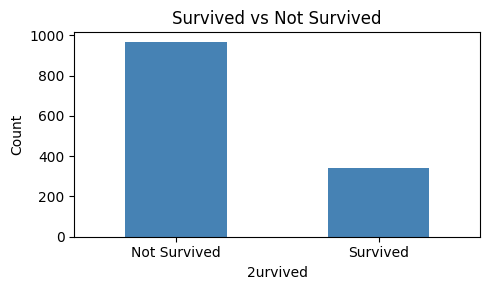

✅ Preprocessing done!
Features used: ['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked']


In [5]:
target_col = '2urvived'
# Step 4: Clean & Preprocess

# Drop useless columns
df.drop(columns=['Passengerid'], inplace=True, errors='ignore')

# Drop all 'zero' columns
zero_cols = [col for col in df.columns if 'zero' in col.lower()]
df.drop(columns=zero_cols, inplace=True)

# Set target column
target_col = '2urvived'

# Encode non-numeric columns
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# Fill missing values
df.fillna(df.mean(), inplace=True)

# Split features and target
X = df.drop(target_col, axis=1)
y = df[target_col]

# Class distribution
plt.figure(figsize=(5, 3))
y.value_counts().plot(kind='bar', color='steelblue')
plt.title("Survived vs Not Survived")
plt.xticks([0, 1], ['Not Survived', 'Survived'], rotation=0)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("✅ Preprocessing done!")
print("Features used:", X.columns.tolist())

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 1047 rows | Test: 262 rows


In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":        DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {"model": model, "y_pred": y_pred, "accuracy": acc}
    print(f"{name}: Accuracy = {acc:.4f}")

Logistic Regression: Accuracy = 0.7519
Decision Tree: Accuracy = 0.7595
Random Forest: Accuracy = 0.7634


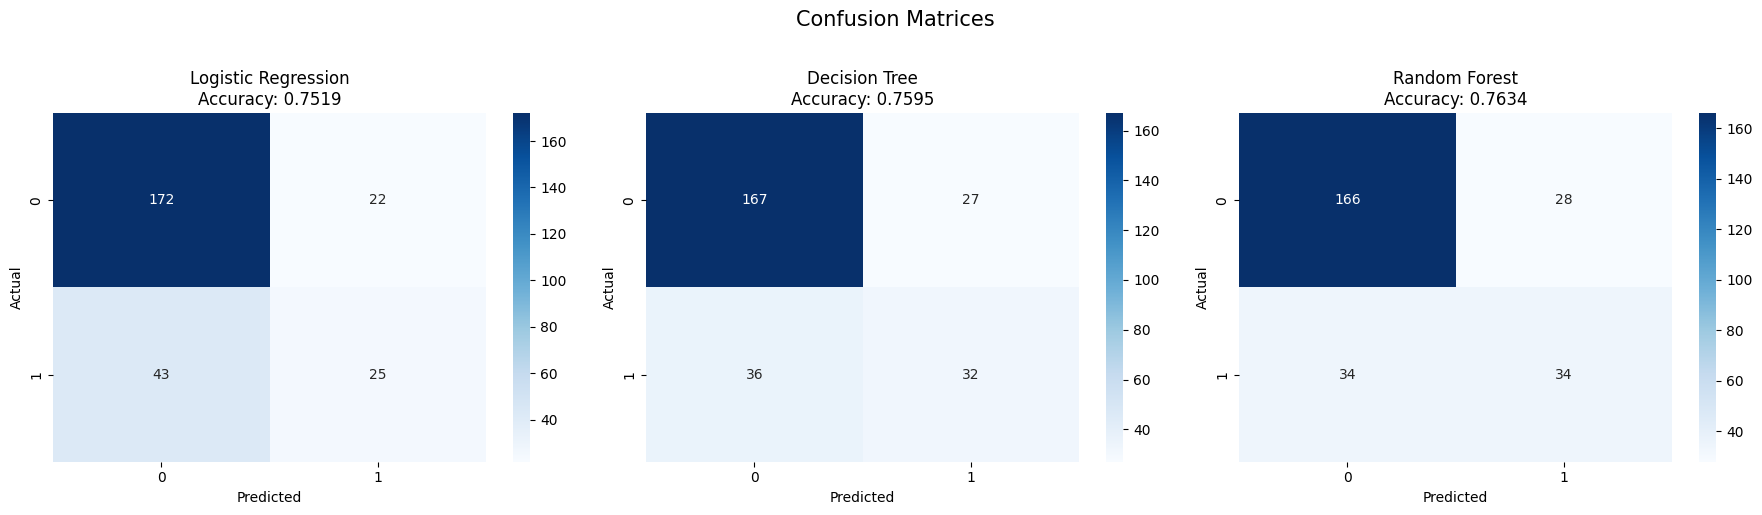

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f"{name}\nAccuracy: {res['accuracy']:.4f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

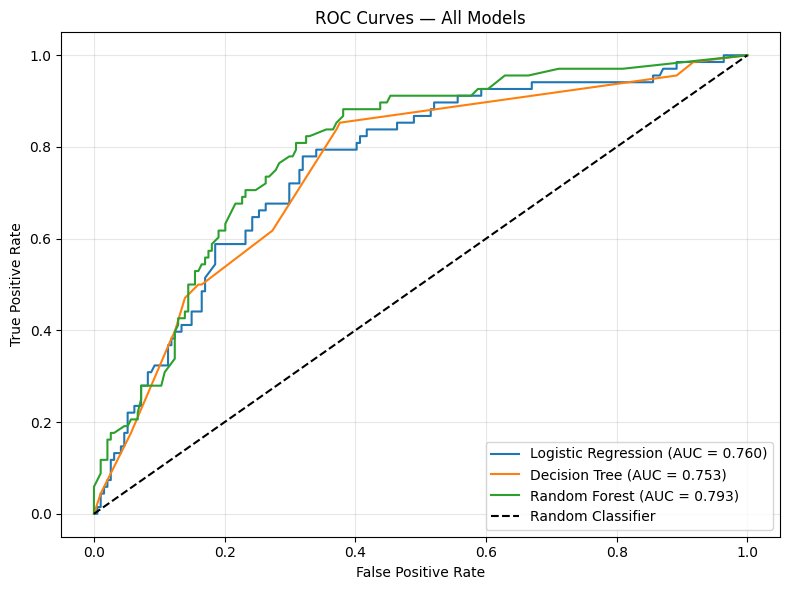

In [9]:
plt.figure(figsize=(8, 6))

for name, res in results.items():
    model = res["model"]
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

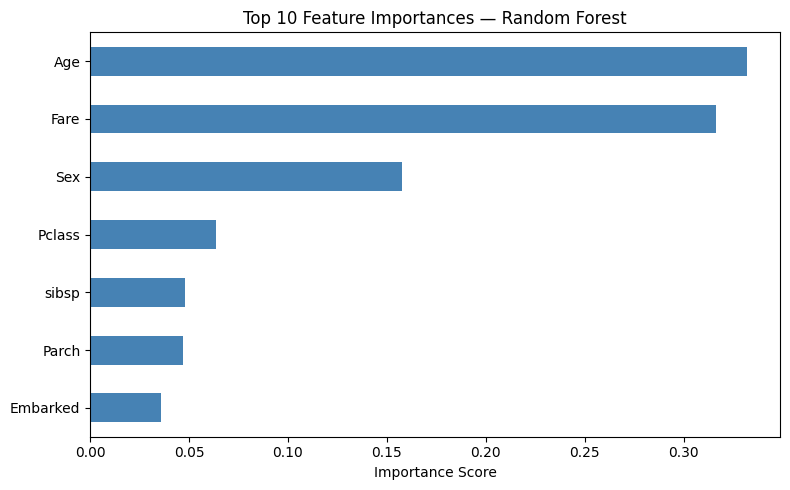

In [10]:
rf_model = results["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top10 = importances.nlargest(10)

plt.figure(figsize=(8, 5))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [11]:
best_name = max(results, key=lambda k: results[k]["accuracy"])
print(f"🏆 Best Model: {best_name}\n")
print(classification_report(y_test, results[best_name]["y_pred"]))

print("=" * 40)
for name, res in results.items():
    bar = "█" * int(res["accuracy"] * 30)
    print(f"{name:<25} {res['accuracy']:.4f}  {bar}")
print("=" * 40)
print("✅ Project Complete!")

🏆 Best Model: Random Forest

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       194
           1       0.55      0.50      0.52        68

    accuracy                           0.76       262
   macro avg       0.69      0.68      0.68       262
weighted avg       0.76      0.76      0.76       262

Logistic Regression       0.7519  ██████████████████████
Decision Tree             0.7595  ██████████████████████
Random Forest             0.7634  ██████████████████████
✅ Project Complete!
